In [19]:
import numpy as np
import cv2
import skimage.morphology as skm
from skimage import measure, color

def image_segmentation(path_img, size_img, display_results = True):
    #================================================================
    # Read the image and convert it to gray scale

    img = path_img
    gray_img = cv2.cvtColor(img,cv2.COLOR_BGR2GRAY)

    #================================================================
    # Preprocessing of the image

    # sharpen operation 
    kernel_pre1 = np.array([[0, -1, 0],[-1, 5, -1],[0, -1, 0]])
    #kernel_pre1 = np.array([[-1, -1, -1, -1, -1],[-1, -1, -1, -1, -1],[-1, -1, 27, -1, -1], [-1, -1, -1, -1, -1], [-1, -1, -1, -1, -1]])
    #kernel_pre = np.array([[-1, -1, -1], [-1, 9, -1], [-1, -1, -1]])
    img_sharpen = cv2.filter2D(gray_img,-1,kernel_pre1)

    # gaussien blur operation 
    kernel_pre2 = np.array([[1, 4, 6, 4, 1],[4, 16, 24, 16, 4],[6, 24, 36, 24, 6], [4, 16, 24, 16, 4], [1, 4, 6, 4, 1]])/256  
    img_blur = cv2.filter2D(img_sharpen,-1,kernel_pre2)
    #img_smooth = cv2.medianBlur(img_sharpen,3)

    #================================================================
    # edges extraction based on the adaptive treshold

    img_AT_1 = cv2.adaptiveThreshold(img_blur, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY, 9, 3)
    closing1 = skm.area_closing(img_AT_1, area_threshold=15, connectivity=1)

    #================================================================
    # Extraction of sure forground using distance transform, treshold and opening algorithms

    # distance transform allow more controle than erosion
    dist_transform = cv2.distanceTransform(closing1,cv2.DIST_L2,3)
    ret1, sure_fg1 = cv2.threshold(dist_transform, 0.1*dist_transform.max(), 255, cv2.THRESH_BINARY)

    kernel = np.ones((3,3),np.uint8)
    opening = cv2.morphologyEx(sure_fg1, cv2.MORPH_OPEN, kernel, iterations = 1)
    sure_fg2 = opening.astype(np.uint8)

    #================================================================
    # Creating background image (white image all value == 255)
    # we don't need to use dilation because in our case we dont have a background 

    sure_bg = np.full(size_img, 255, np.uint8)
    #kernel = np.ones((3,3),np.uint8)
    #sure_bg = cv2.dilate(sure_fg2, kernel, iterations = 100)

    #================================================================
    # Finding unknown region

    unknown1 = cv2.subtract(sure_bg,sure_fg2)

    #================================================================
    # preparing markers

    # Marker labelling
    ret1, markers1 = cv2.connectedComponents(sure_fg2)
    # Add one to all labels so that sure background is not 0, but 1
    markers1 = markers1 + 1
    # Now, mark the region of unknown with zero
    markers1[unknown1==255] = 0

    #================================================================
    # apply watershed algorithm

    markers1 = cv2.watershed(img,markers1)
    markers1_img = markers1.astype(np.uint8)
    markers1b = color.label2rgb(markers1, bg_label=0)

    #================================================================
    
    
    if display_results == True:
        img1 = np.copy(img)
        img1[markers1 == -1] = [0,0,255]
        cv2.imshow("img1",img1)
        cv2.imshow("gray_img",gray_img)
        cv2.imshow("img_sharpen",img_sharpen)
        cv2.imshow("img_blur",img_blur)
        cv2.imshow("img_AT_1",img_AT_1)
        cv2.imshow("closin1",closing1)
        cv2.imshow("sure_fg1",sure_fg1)
        cv2.imshow("opening",opening)
        cv2.imshow("sure_fg2",sure_fg2)
        cv2.imshow("sure_bg",sure_bg)
        cv2.imshow("markers1_img",markers1_img)


    cv2.waitKey(0) 
    cv2.destroyAllWindows()
    
    return markers1, gray_img

In [20]:
def bubble_size_measurements(markers, gray_img, list_max_group_perimeters, list_max_group_areas, pixels_to_mm):
    ### this function arrange perimeters and areas into groups and returns :
        # the total number of bubbles in an image
        # a list of percentage of number of items in each group 
        # a average perimeter and the average area in each group
    
    regions = measure.regionprops(markers, intensity_image=gray_img)
    pixels_to_mm = 1 # Determine how many pixels are in each mm
    perimeters_list = []
    areas_list = []

    for region in regions:
        perimeters_list.append(region['perimeter'] * pixels_to_mm)
        areas_list.append(region['area'] * pixels_to_mm**2)
        
    # Calculate the total number of bubbles 
    total_number = len(regions)
    
    # Creat groupes of perimeters and areas
    list_groups_perimeters = []
    list_groups_areas = []
    for i in range(len(list_max_group_perimeters) + 1):
        list_groups_perimeters.append([])
        list_groups_areas.append([])
    
    # Arrange perimeters and areas into groups
    for (perimeter, area) in zip(perimeters_list, areas_list):
        i = 0 # the index of a groupe of perimeters in list_groups_perimeters (same with areas)
        perimeter_appended = False
        area_appended = False
        for (max_group_perimeters, max_group_areas) in zip(list_max_group_perimeters, list_max_group_areas):
            if perimeter <= max_group_perimeters and perimeter_appended == False:
                list_groups_perimeters[i].append(perimeter)
                perimeter_appended = True
                
            if area <= max_group_areas and area_appended == False:
                list_groups_areas[i].append(area)
                area_appended = True
                
            i = i+1 # we pass to the next groupe of perimeters or areas
        
        # for the last groupe    
        if perimeter > list_max_group_perimeters[i-1] and perimeter_appended == False:
                list_groups_perimeters[i].append(perimeter)
                perimeter_appended = True
                
        if area > list_max_group_areas[i-1] and area_appended == False:
            list_groups_areas[i].append(area)
            area_appended = True
            
    # Calculate the percentage and the average for each group
    list_percentages = []
    list_averages = []
    for (group_p, group_a) in zip(list_groups_perimeters, list_groups_areas):
        
        ####################################################################
        # Calculate the percentage of number of items in each group
        ####################################################################
        percentage = {}
        
        ### for the group of perimeters
        if group_p: # if the list group_p is not empty
            p = len(group_p) / total_number
            p = p*100
            percentage["perimeters"] = p
        else :
            percentage["perimeters"] = 0
            
        ### for the group of areas
        if group_a: # if the list group_p is not empty
            p = len(group_a) / total_number
            p = p*100
            percentage["areas"] = p
        else :
            percentage["areas"] = 0
            
        list_percentages.append(percentage)
        
        ####################################################################
        # Calculate the average perimeter and the average area in each group
        ####################################################################
        average = {}
        
        ### for the group perimeters
        if group_p: # if the list group_p is not empty
            a = sum(group_p) / len(group_p)
            average["perimeter"] = a
        else:
            average["perimeter"] = -1
            
        ### for the group areas
        if group_a: # if the list group_p is not empty
            a = sum(group_a) / len(group_a)
            average["area"] = a
        else:
            average["area"] = -1
            
        list_averages.append(average)
        
    return total_number, list_percentages, list_averages
                

In [21]:
def bubble_size_distribution(path_img, size_img, list_max_group_perimeters, list_max_group_areas, pixels_to_mm, display_results = True):
    # segment the image
    markers, gray_img = image_segmentation(path_img, size_img, display_results)
    # extract bubble size measurements
    total_number, list_percentages, list_averages = bubble_size_measurements(markers, gray_img, list_max_group_perimeters, list_max_group_areas, pixels_to_mm)
    
    return total_number, list_percentages, list_averages

In [22]:
# read the video 

cap = cv2.VideoCapture('rl4_pb17-4.mp4')

cap.set(cv2.CAP_PROP_POS_MSEC, 7500)
ret, frame = cap.read()

path_img = './dep_img/rl3_pb17-4-1.jpg'
size_img = (frame.shape[0], frame.shape[1])
list_max_group_perimeters = [100, 300, 500]
list_max_group_areas = [500, 1000, 2000]
pixels_to_mm = 1

total_number, list_percentages, list_averages = bubble_size_distribution(frame, size_img, list_max_group_perimeters, list_max_group_areas, pixels_to_mm, display_results = True)
# if display_results == True the function will display the images results in each step of segmentation 

print(total_number)


223


In [23]:
print(list_percentages)
print(list_averages)

[{'perimeters': 17.937219730941703, 'areas': 25.56053811659193}, {'perimeters': 52.91479820627802, 'areas': 16.143497757847534}, {'perimeters': 17.040358744394617, 'areas': 22.869955156950674}, {'perimeters': 12.10762331838565, 'areas': 35.42600896860987}]
[{'perimeter': 68.94922074112304, 'area': 279.2105263157895}, {'perimeter': 191.32059231920942, 'area': 715.0}, {'perimeter': 368.7846251840425, 'area': 1449.6274509803923}, {'perimeter': 977.8437972366465, 'area': 9801.291139240506}]


In [24]:
# read the video 

cap = cv2.VideoCapture('rl4_pb17-4.mp4')

cap.set(cv2.CAP_PROP_POS_MSEC, 7700)
ret, frame = cap.read()

path_img = './dep_img/rl3_pb17-4-1.jpg'
size_img = (frame.shape[0], frame.shape[1])
list_max_group_perimeters = [100, 300, 500]
list_max_group_areas = [500, 1000, 2000]
pixels_to_mm = 1

total_number, list_percentages, list_averages = bubble_size_distribution(frame, size_img, list_max_group_perimeters, list_max_group_areas, pixels_to_mm, display_results = True)
# if display_results == True the function will display the images results in each step of segmentation 

print(total_number)
#print(list_percentages)
#print(list_averages)

277


In [25]:
# read the video

cap = cv2.VideoCapture('rl4_pb17-4.mp4')

# getting the frame rate
fps = cap.get(cv2.CAP_PROP_FPS)

print(f"video fps: {fps}")

# getting the frame count
frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

print(f"video frame count: {frame_count}")


video fps: 29.703158414733778
video frame count: 938


In [26]:
# frame resolution
frame_width = int(cap.get(3))
frame_height = int(cap.get(4))

print(f"video frame resolution: {frame_width} x {frame_height}")


video frame resolution: 1280 x 720


In [27]:
Bubble_number_list = []
for i in range(0, frame_count):
    cap.set(cv2.CAP_PROP_POS_FRAMES, i)
    ret, frame = cap.read()
    if ret:
        total_number, list_percentages, list_averages = bubble_size_distribution(frame, size_img, list_max_group_perimeters, list_max_group_areas, pixels_to_mm, display_results = False)
        Bubble_number_list.append(total_number)
    else:
        print(f"frame {i} is not read")

In [28]:
print(Bubble_number_list)

[511, 572, 511, 625, 586, 431, 489, 434, 427, 380, 320, 343, 336, 268, 363, 299, 302, 343, 331, 215, 224, 284, 280, 213, 295, 231, 308, 214, 184, 247, 278, 243, 208, 172, 178, 209, 238, 256, 222, 240, 211, 169, 182, 199, 255, 270, 294, 245, 322, 311, 385, 428, 434, 375, 348, 308, 365, 389, 406, 443, 454, 452, 432, 415, 596, 598, 444, 436, 425, 384, 371, 370, 364, 297, 233, 239, 247, 284, 290, 348, 344, 321, 404, 371, 310, 414, 535, 417, 361, 414, 389, 405, 302, 394, 413, 376, 437, 339, 345, 344, 407, 360, 403, 259, 189, 275, 187, 242, 257, 281, 553, 300, 290, 291, 232, 179, 308, 318, 302, 314, 335, 321, 308, 317, 311, 304, 303, 309, 294, 292, 306, 287, 235, 243, 231, 242, 258, 238, 258, 264, 262, 259, 294, 295, 375, 399, 426, 419, 359, 280, 255, 338, 372, 334, 313, 327, 267, 256, 249, 289, 279, 328, 322, 235, 334, 297, 303, 460, 461, 443, 373, 522, 511, 512, 502, 485, 481, 457, 418, 415, 482, 453, 434, 431, 349, 316, 315, 272, 321, 324, 271, 294, 256, 266, 336, 322, 313, 319, 343, 422,

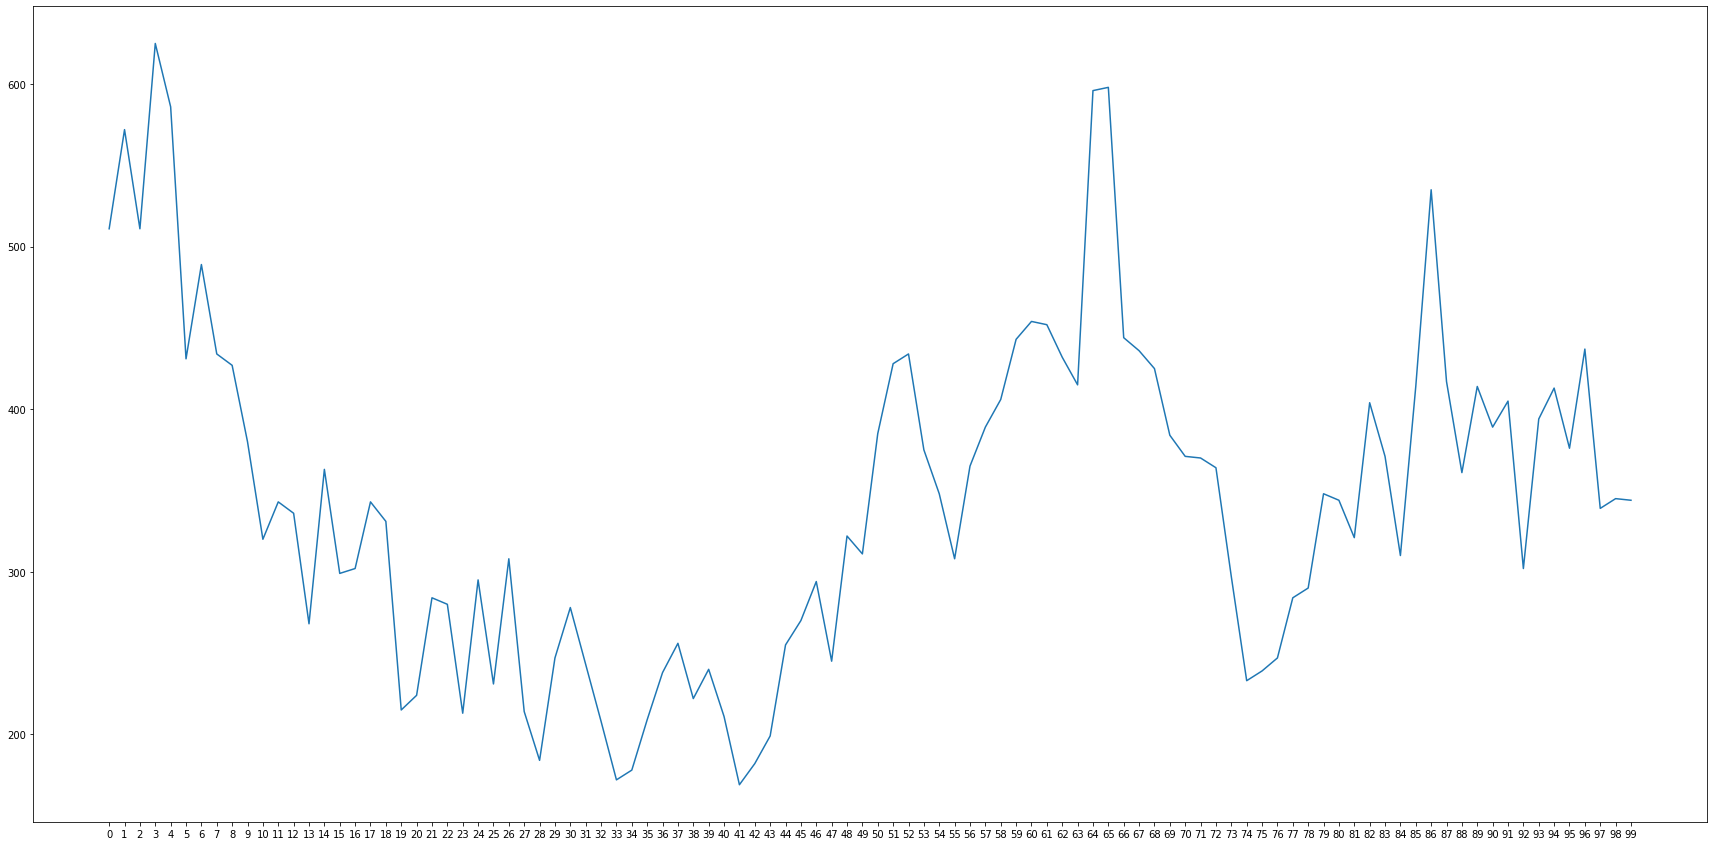

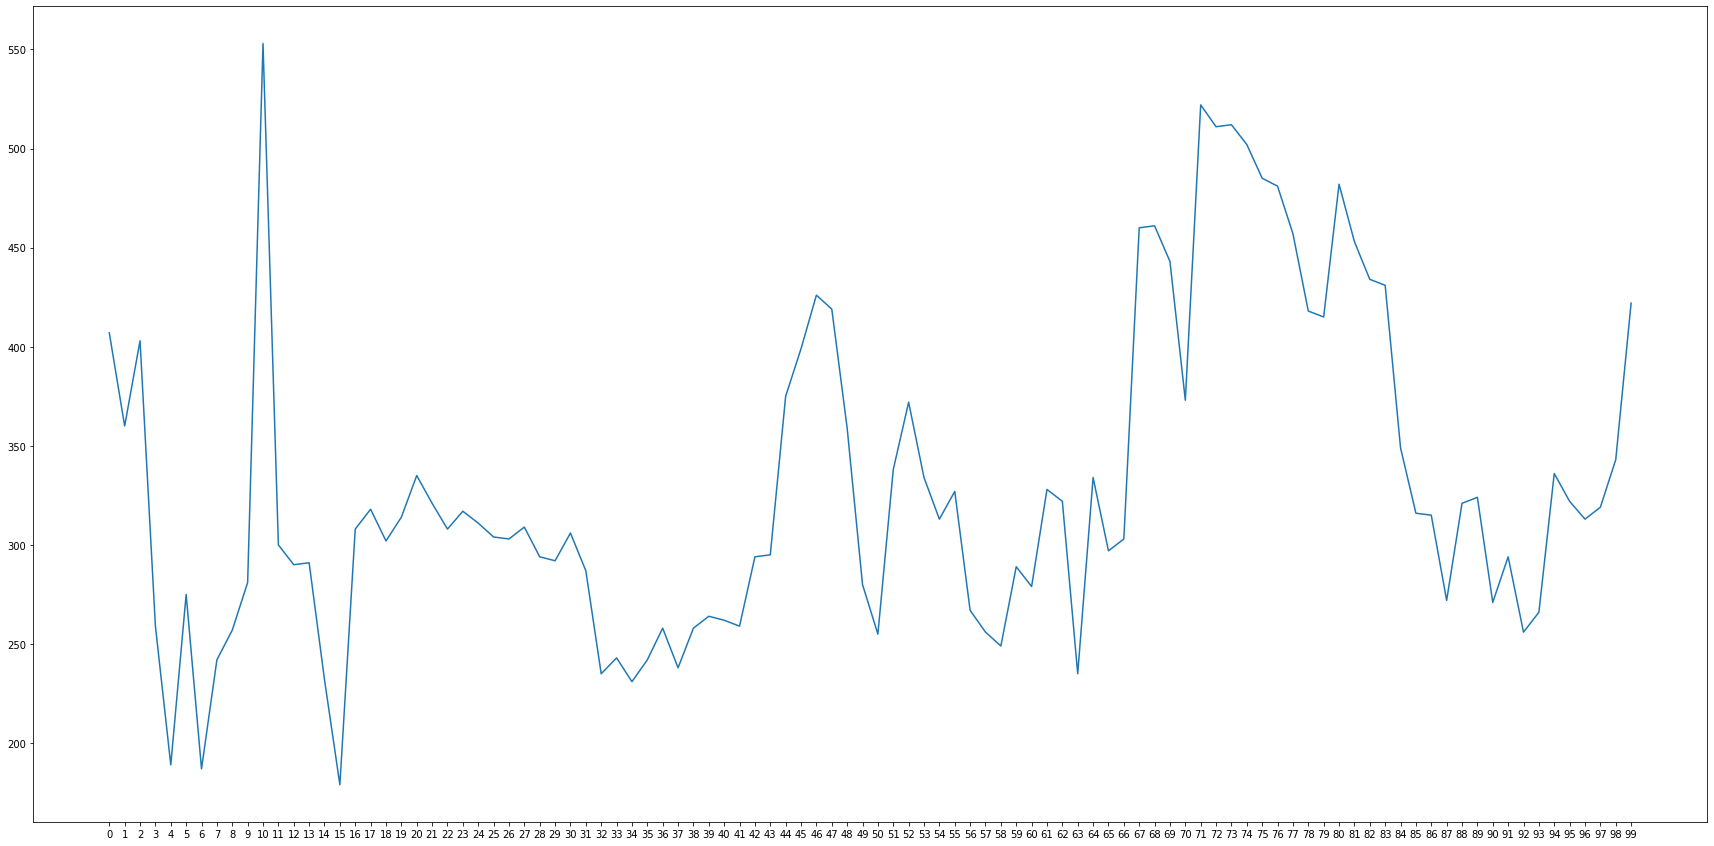

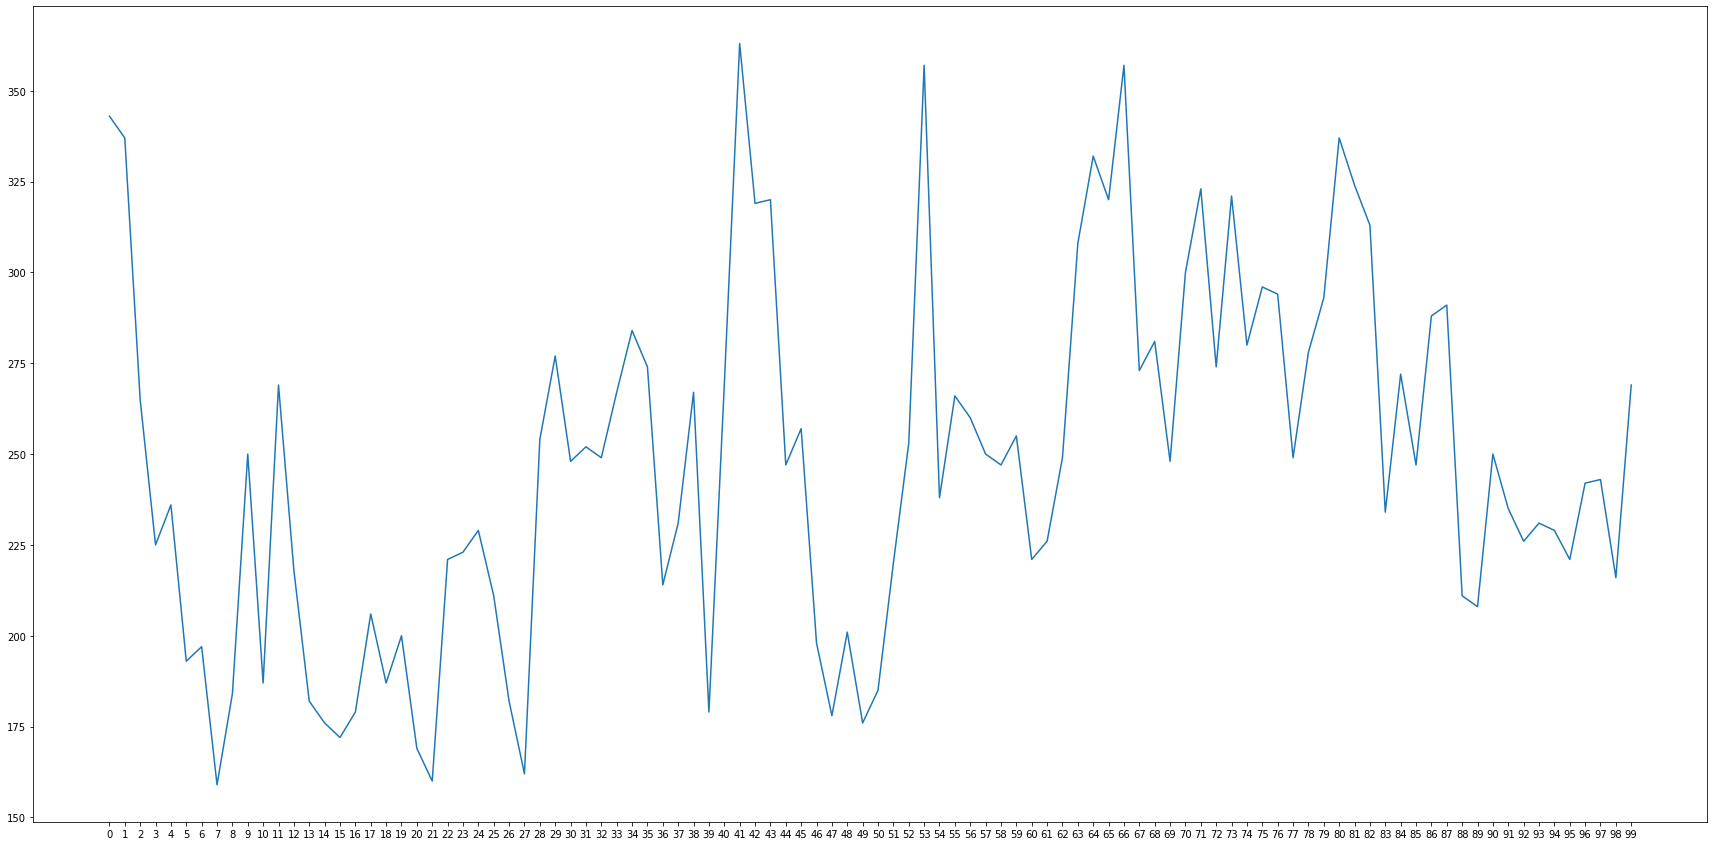

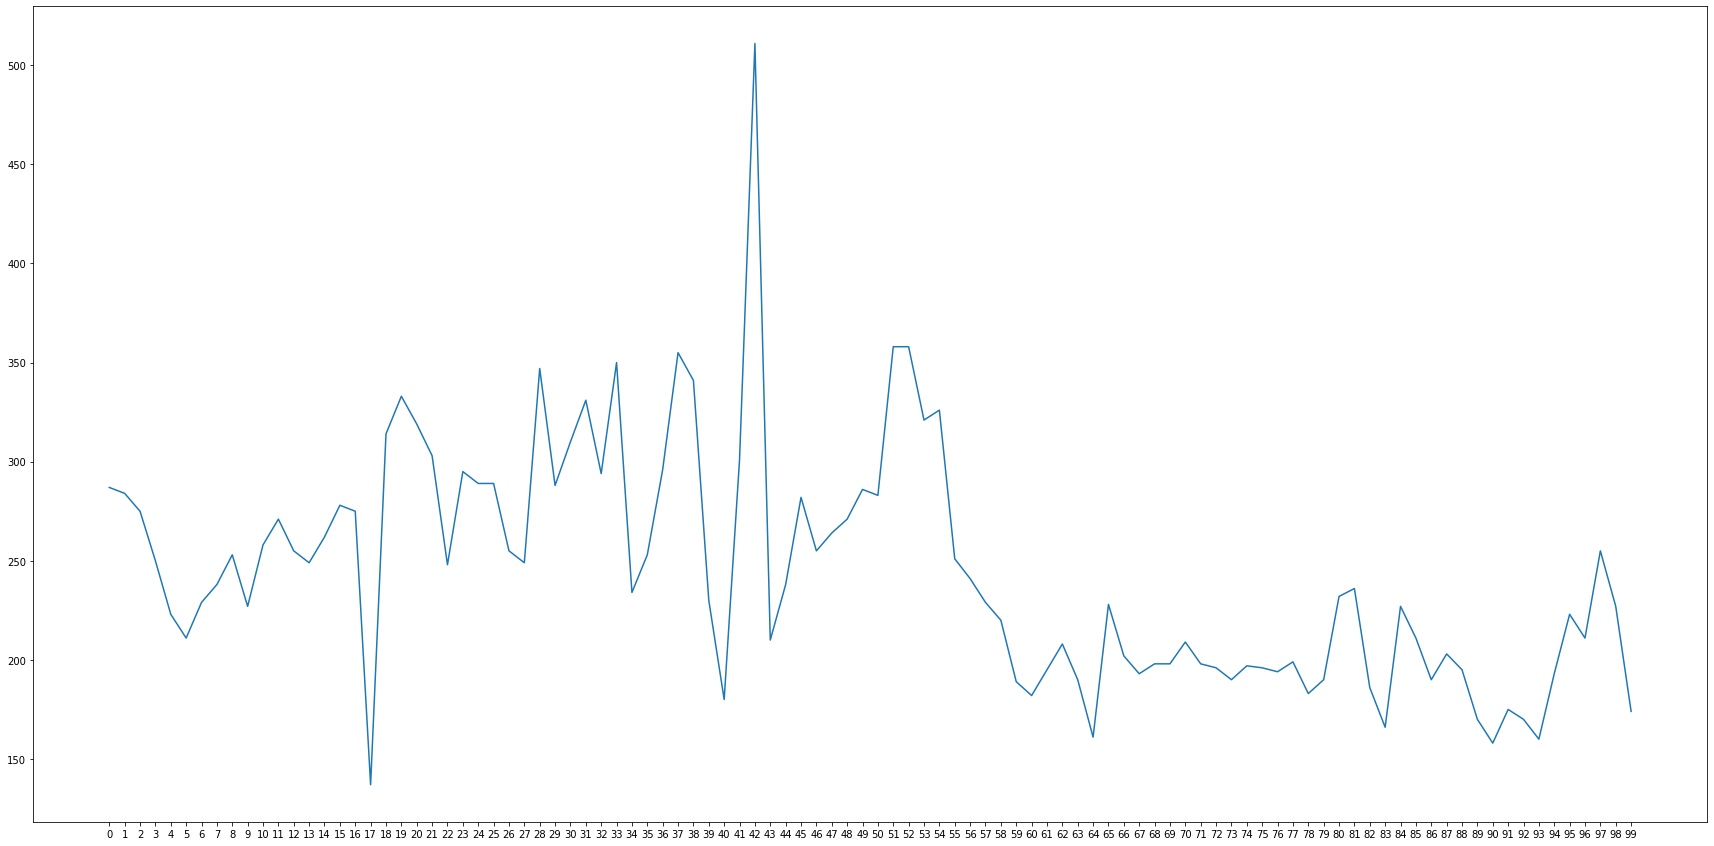

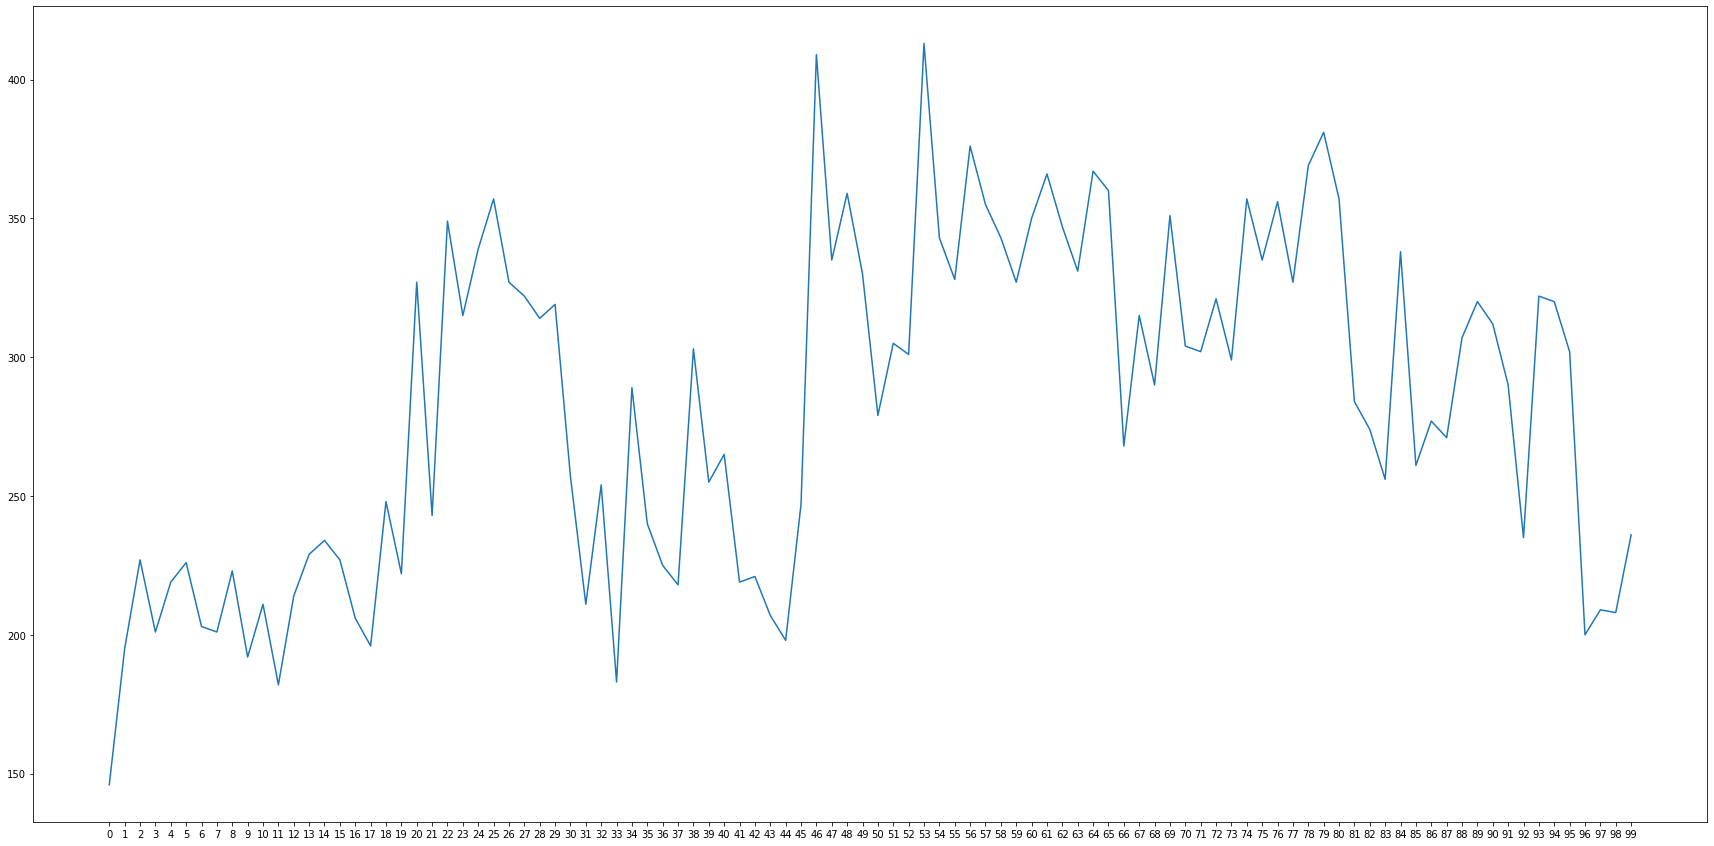

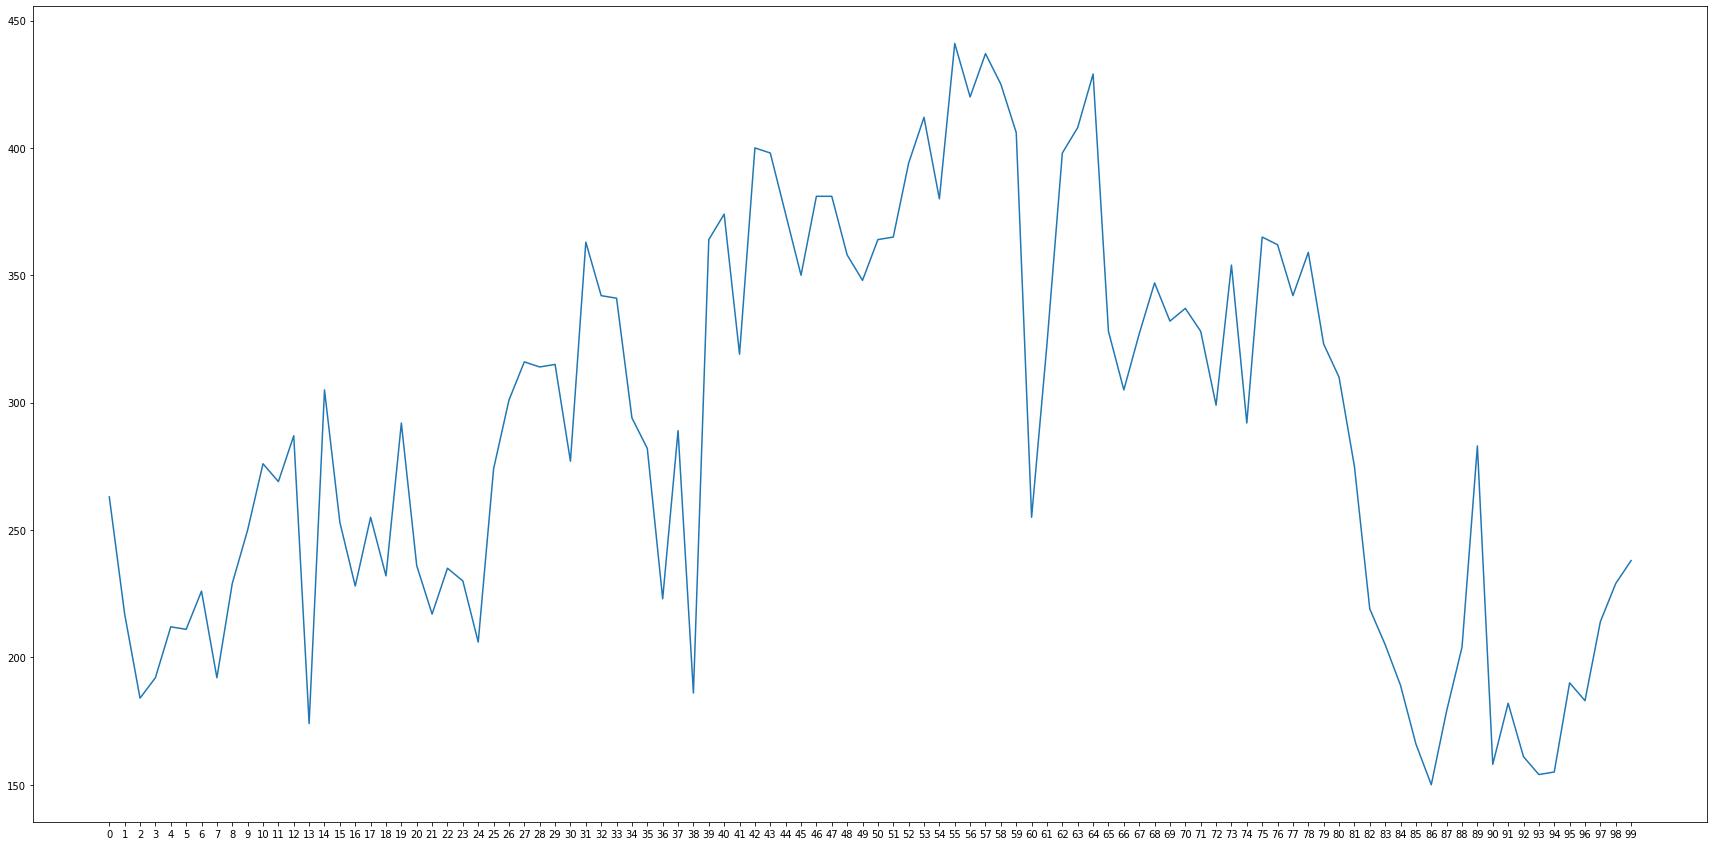

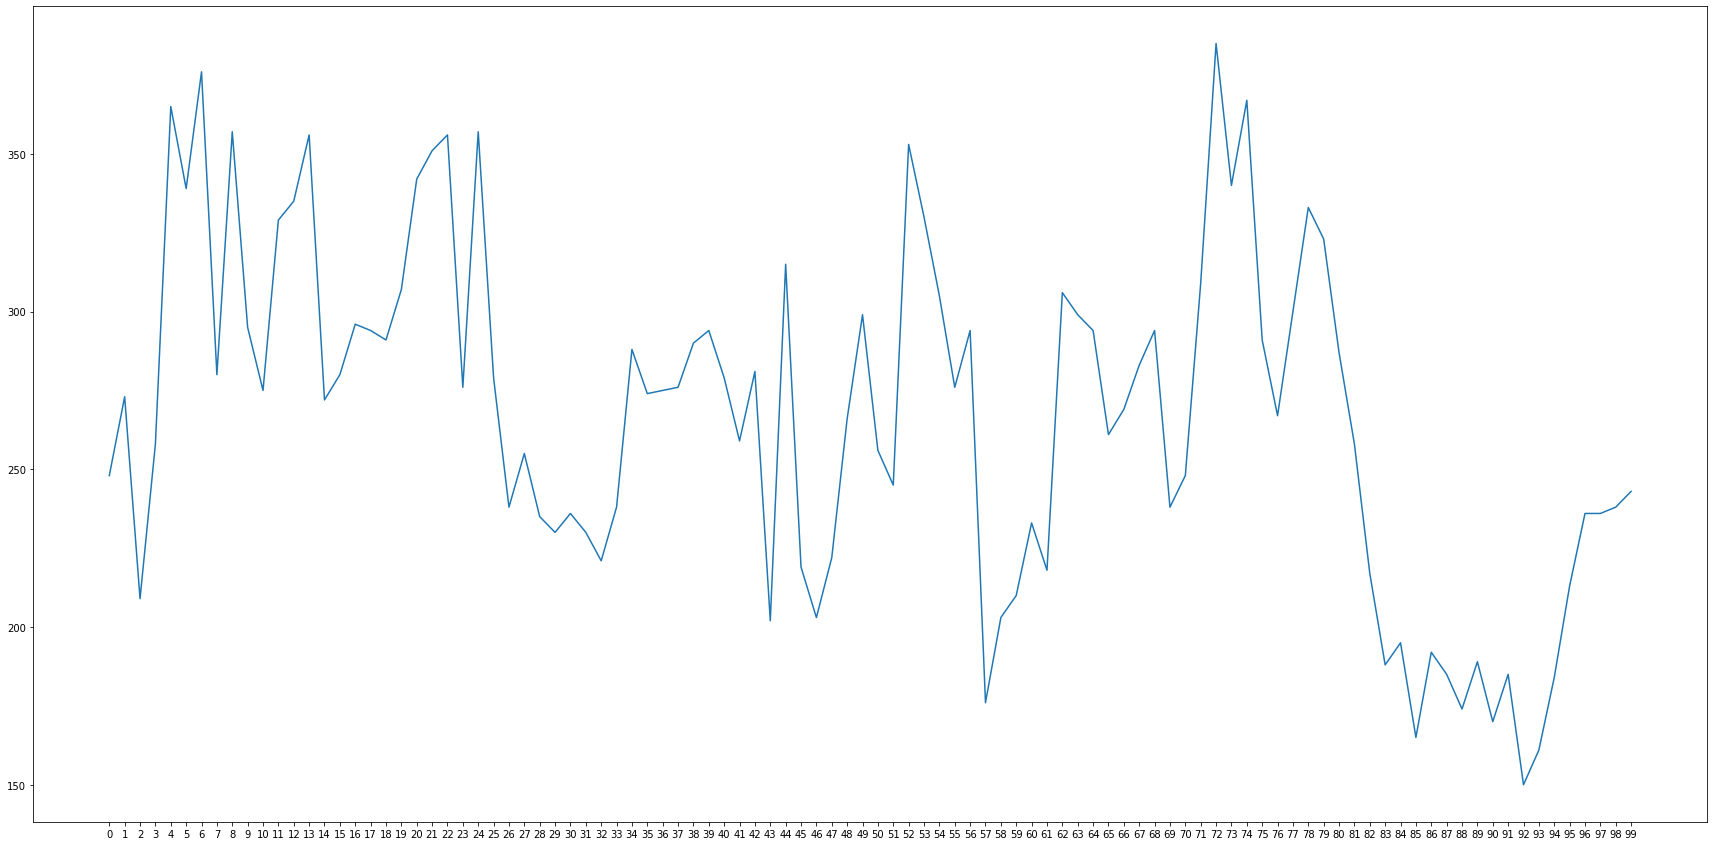

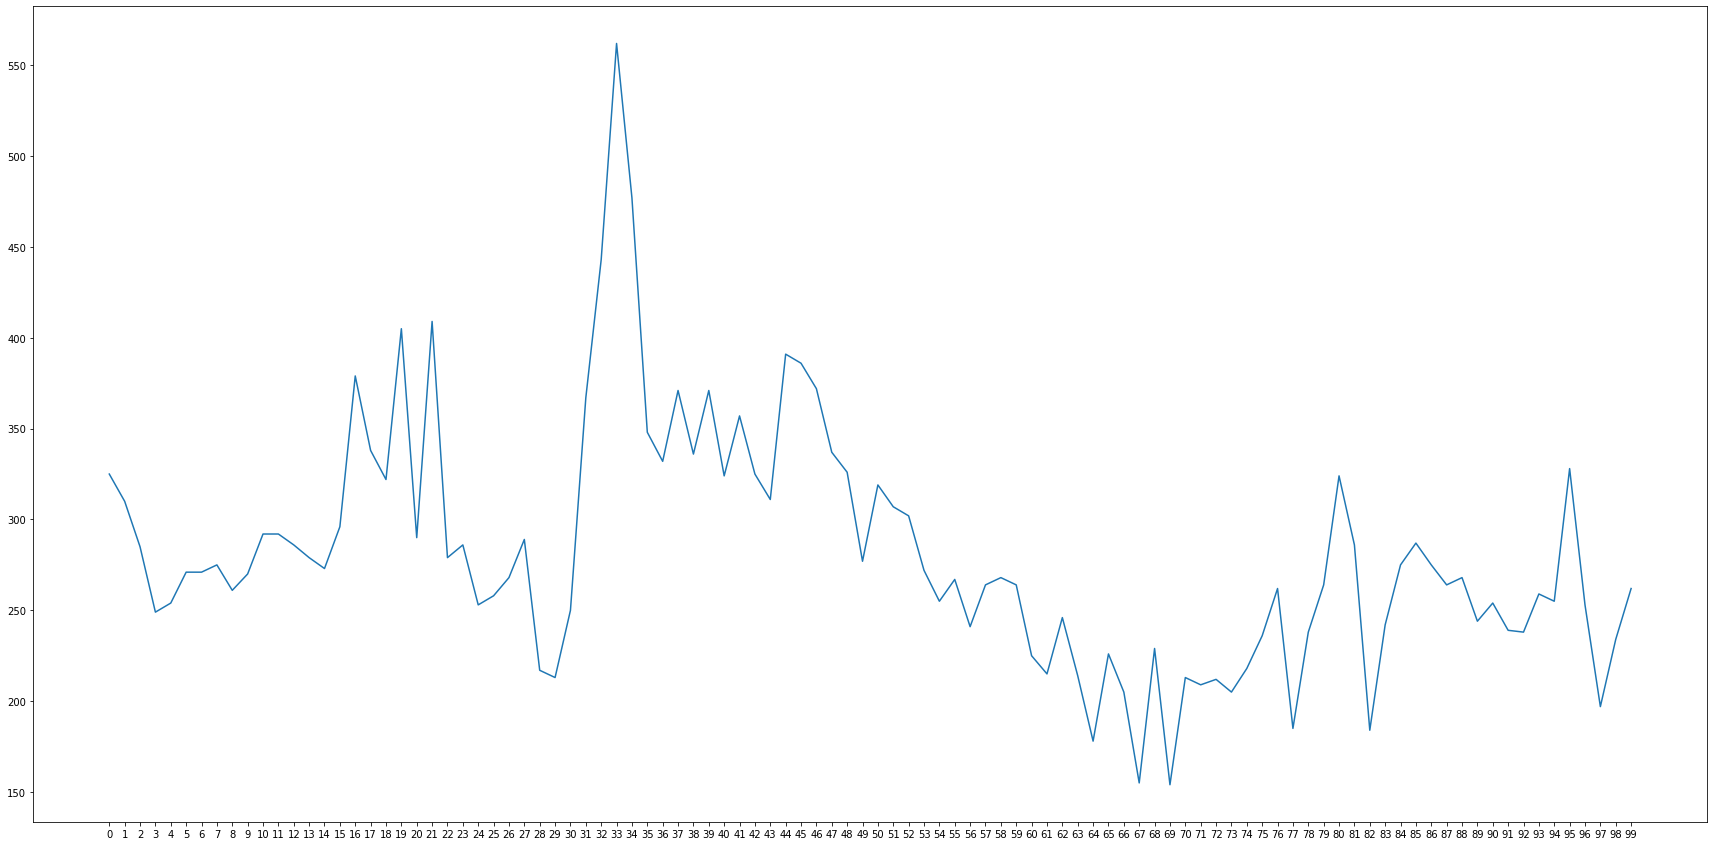

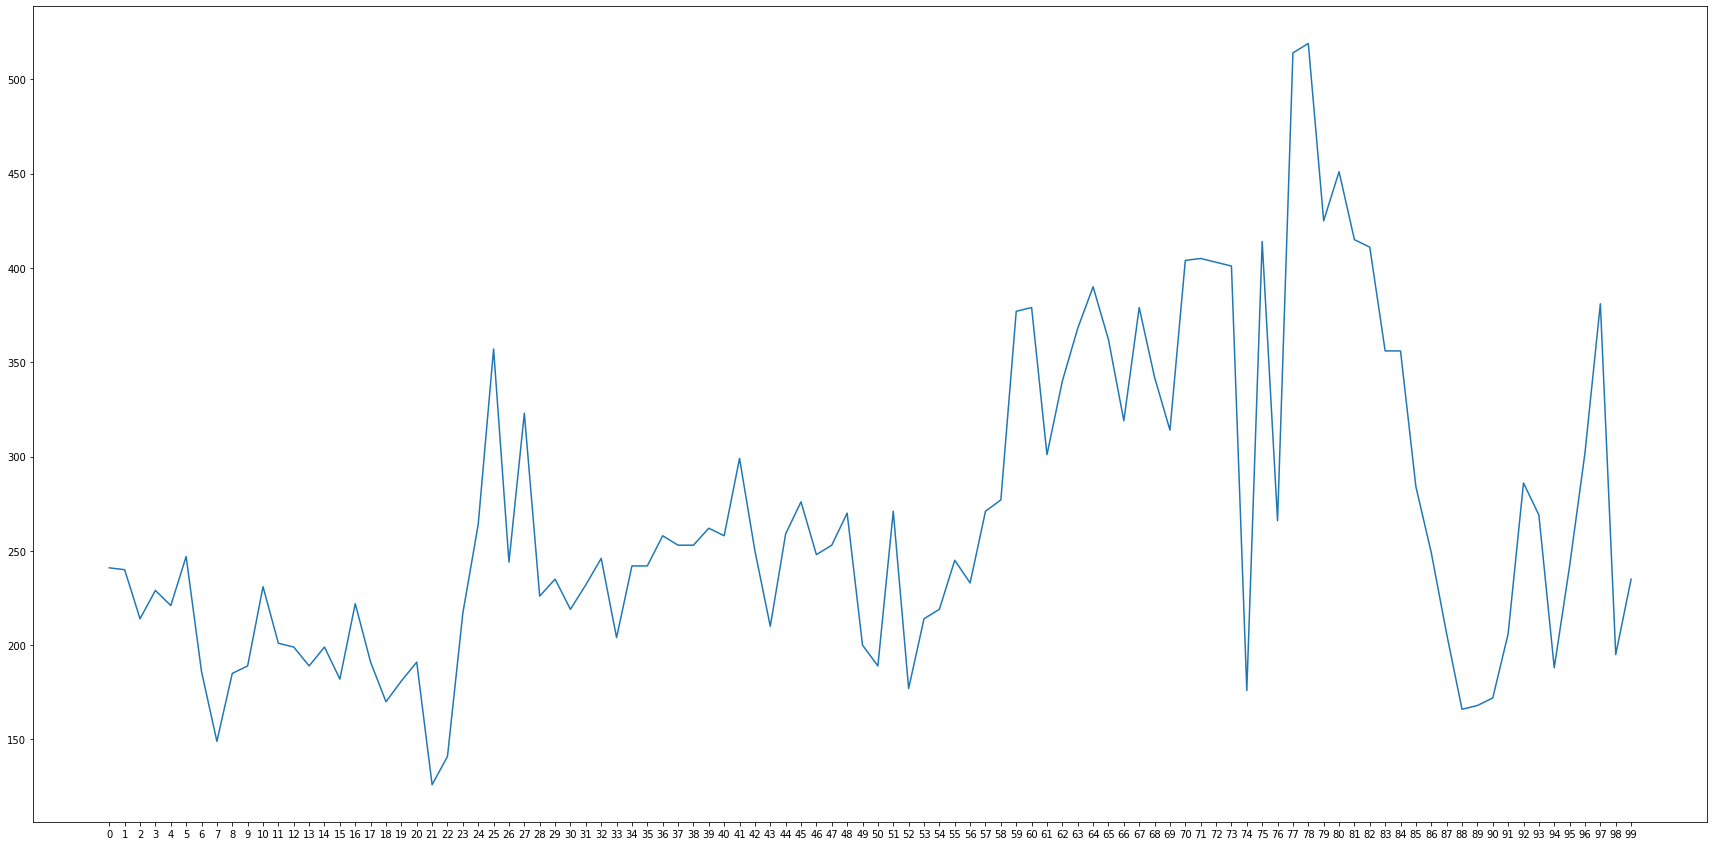

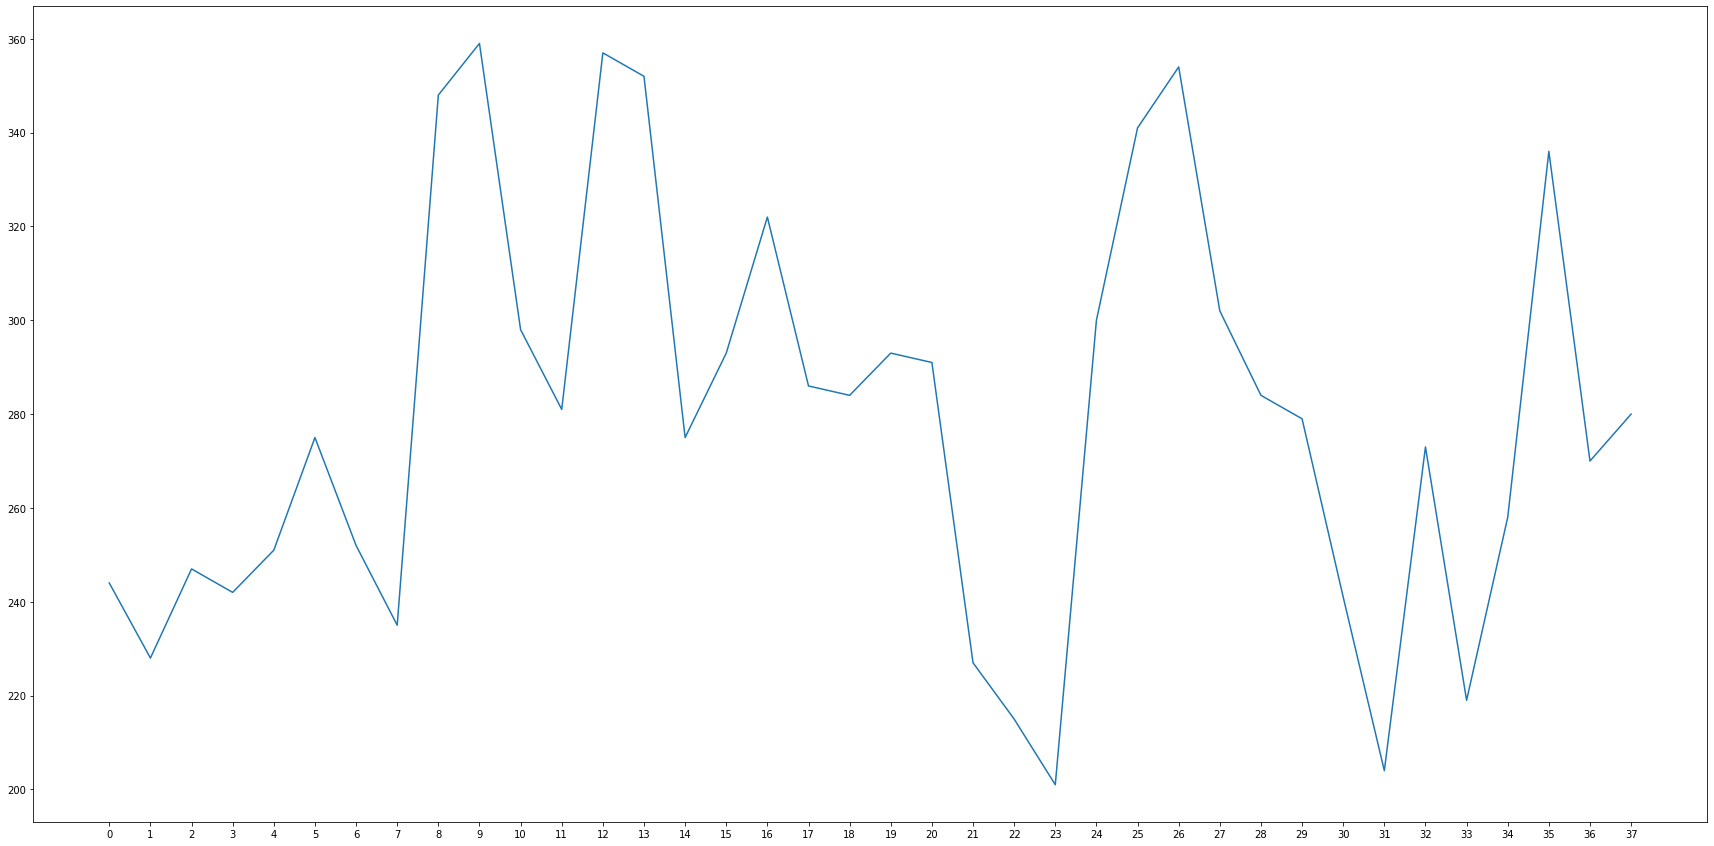

In [29]:
#plot the bubble number over time each 100 value in a plot
import matplotlib.pyplot as plt
import numpy as np

for i in range(0, len(Bubble_number_list), 100):
    plt.figure(figsize=(30,15))
    plt.xticks(np.arange(0, len(Bubble_number_list[i:i+100]), 1))
    plt.plot(Bubble_number_list[i:i+100])
    plt.show()
